# **UCI HAR - SEnet**
SE는 정보의 압축(Squeeze) + 중요도 계산(Excitation)을 통해 성능을 향상

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input, Model, backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, GlobalAveragePooling1D, Dense, Reshape, Multiply, MaxPooling1D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [ ]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/drive/MyDrive/AI_Study/UCI_HAR_Dataset/"

In [ ]:
# Load "X"
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []                                        # 한 센서축 데이터 전체 저장

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')              # 공백 2개를 1개로
                row_clean = row_clean.strip()                   # 양쪽 공백 제거
                serie = row_clean.split(' ')                    # 공백 기준 split
                serie_array = np.array(serie, dtype=np.float32) # float32 numpy 배열로 변환
                series_list.append(serie_array)                 # 시퀀스 추가

        # 하나의 센서축 데이터 추가 (feature)
        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)
    # shape 변환 → (샘플 수, 타임스텝 수, 특성 수)
    return np.transpose(X_signals, (1, 2, 0))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("첫 번째 샘플 데이터:\n", X_train[0])

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
첫 번째 샘플 데이터:
 [[ 1.808515e-04  1.076681e-02  5.556068e-02 ...  1.012817e+00
  -1.232167e-01  1.029341e-01]
 [ 1.013856e-02  6.579480e-03  5.512483e-02 ...  1.022833e+00
  -1.268756e-01  1.056872e-01]
 [ 9.275574e-03  8.928878e-03  4.840473e-02 ...  1.022028e+00
  -1.240037e-01  1.021025e-01]
 ...
 [-1.147484e-03  1.714439e-04  2.647864e-03 ...  1.018445e+00
  -1.240696e-01  1.003852e-01]
 [-2.222655e-04  1.574181e-03  2.381057e-03 ...  1.019372e+00
  -1.227451e-01  9.987355e-02]
 [ 1.575500e-03  3.070189e-03 -2.269757e-03 ...  1.021171e+00
  -1.213260e-01  9.498741e-02]]


In [ ]:
# Load "y"

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 라벨을 0부터 시작하도록 -1 (원래 라벨이 1부터 시작)
    return np.array(labels, dtype=np.int32) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

# 정답 레이블을 원-핫 인코딩으로 변환 (클래스 개수 = 6)
y_train_onehot = to_categorical(y_train, num_classes=6)
y_test_onehot = to_categorical(y_test, num_classes=6)

print("원본 정답 쉐입:", y_train.shape)              # (7352,)
print("원-핫 인코딩 후 쉐입:", y_train_onehot.shape) # 변환 후: (7352, 6)

print(y_train_onehot[:5])

원본 정답 쉐입: (7352,)
원-핫 인코딩 후 쉐입: (7352, 6)
[[0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]]


In [ ]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = 6

K.clear_session()

# --- SE (Squeeze-and-Excitation) 블록 정의 ---
def se_block(input_tensor, reduction_ratio=16):
    # 원래 채널 수 확인
    channels = input_tensor.shape[-1]

    # 1. Squeeze: 글로벌 에버리지 풀링을 통해 채널별 전역 정보를 1차원 벡터로 압축
    # 변환 형태: (Batch, Length, Channels) -> (Batch, Channels)
    squeeze = GlobalAveragePooling1D()(input_tensor)

    # 2. Excitation: 채널 간의 상호작용 및 중요도(가중치) 계산
    # 뉴런 수를 1/reduction_ratio 로 줄였다가 다시 원래 채널 수로 확장
    excitation = Dense(channels // reduction_ratio, activation='relu')(squeeze)
    excitation = Dense(channels, activation='sigmoid')(excitation) # 각 채널의 가중치를 0~1 사이로 출력

    # 원본 텐서와 곱하기 위해 차원 확장 (Batch, 1, Channels)
    excitation = Reshape((1, channels))(excitation)

    # 3. Scale: 원본 입력 텐서에 계산된 채널별 가중치를 곱해줌
    scale = Multiply()([input_tensor, excitation])
    return scale

# --- 전체 모델 빌딩 ---
inputs = Input(shape=input_shape)

# 첫 번째 특징 추출
x = Conv1D(128, 7, padding='same')(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)
x = se_block(x, reduction_ratio=16) # ★ SE 블록 적용

# 두 번째 특징 추출 (+ MaxPooling으로 압축)
x = Conv1D(256, 5, padding='same')(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = se_block(x, reduction_ratio=16) # ★ SE 블록 적용
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)

# 세 번째 특징 추출
x = Conv1D(256, 5, padding='same')(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = se_block(x, reduction_ratio=16) # ★ SE 블록 적용

# 네 번째 특징 추출 (+ MaxPooling으로 압축)
x = Conv1D(256, 3, padding='same')(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = se_block(x, reduction_ratio=16) # ★ SE 블록 적용
x = MaxPooling1D(2)(x)

# 차원 축소 및 데이터 요약
x = GlobalAveragePooling1D()(x)

# 은닉층 (Dense)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# 최종 출력층 (원-핫 인코딩 대응)
outputs = Dense(num_classes, activation='softmax')(x)

# 모델 생성
model = Model(inputs=inputs, outputs=outputs)

# 컴파일 설정 (원-핫 인코딩 전용)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 128)  │      8,192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │      1,032 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      1,152 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 128)  │          0 │ re_lu[0][0],      │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 256)  │    164,096 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256)  │      1,024 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 256)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ re_lu_1[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │      4,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │      4,352 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 256)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 128, 256)  │          0 │ re_lu_1[0][0],    │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 256)   │          0 │ multiply_1[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 256)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 64, 256)   │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256)   │      1,024 │ conv1d_2[0][0]  

 Total params: 796,606 (3.04 MB)

 Trainable params: 794,302 (3.03 MB)

 Non-trainable params: 2,304 (9.00 KB)

None


In [ ]:
callbacks = [
            ModelCheckpoint(
                "UCI_HAR_SEnet_best.keras",
                save_best_only=True,
                monitor="val_categorical_accuracy",
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor="val_categorical_accuracy",
                patience=25,
                verbose=1,
                mode='max',
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.2,
                patience=8,
                min_lr=0.00001,
                verbose=1
            )
        ]

In [ ]:
history = model.fit(
            X_train, y_train_onehot,
            epochs=100,
            batch_size=16,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

Epoch 1/100
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7937 - loss: 0.5935

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_categorical_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to UCI_HAR_Resnet_best.keras
368/368 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.8670 - loss: 0.3869 - val_accuracy: 0.8056 - val_loss: 0.4812 - learning_rate: 0.0010
Epoch 2/100
 17/368 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9334 - loss: 0.2105

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_categorical_accuracy` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)


362/368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9168 - loss: 0.2377
Epoch 2: finished saving model to UCI_HAR_Resnet_best.keras
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9121 - loss: 0.2340 - val_accuracy: 0.9225 - val_loss: 0.2718 - learning_rate: 0.0010
Epoch 3/100
362/368 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9244 - loss: 0.2008
Epoch 3: finished saving model to UCI_HAR_Resnet_best.keras
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9245 - loss: 0.1939 - val_accuracy: 0.9205 - val_loss: 0.2086 - learning_rate: 0.0010
Epoch 4/100
358/368 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9350 - loss: 0.1581
Epoch 4: finished saving model to UCI_HAR_Resnet_best.keras
368/368 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9362 - loss: 0.1533 - val_accuracy: 0.9273 - val_loss: 0.2269 - learning_rate: 0.0010
Epoch 5/100
359/368 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9475 - loss: 0.1331
Epoch 5: finished saving model to UCI_HAR_Resnet_best.keras
3

In [ ]:
# best 기록 확인
model = tf.keras.models.load_model("UCI_HAR_SEnet_best.keras")

train_loss, train_acc = model.evaluate(X_train, y_train_onehot, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 96.75%
Training loss: 0.0932
Test accuracy: 95.42%
Test loss: 0.1549


In [ ]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9980    1.0000    0.9990       496
           1     0.9936    0.9894    0.9915       471
           2     0.9976    0.9952    0.9964       420
           3     0.8701    0.8595    0.8648       491
           4     0.8858    0.8891    0.8874       532
           5     0.9890    1.0000    0.9944       537

    accuracy                         0.9542      2947
   macro avg     0.9557    0.9555    0.9556      2947
weighted avg     0.9540    0.9542    0.9541      2947



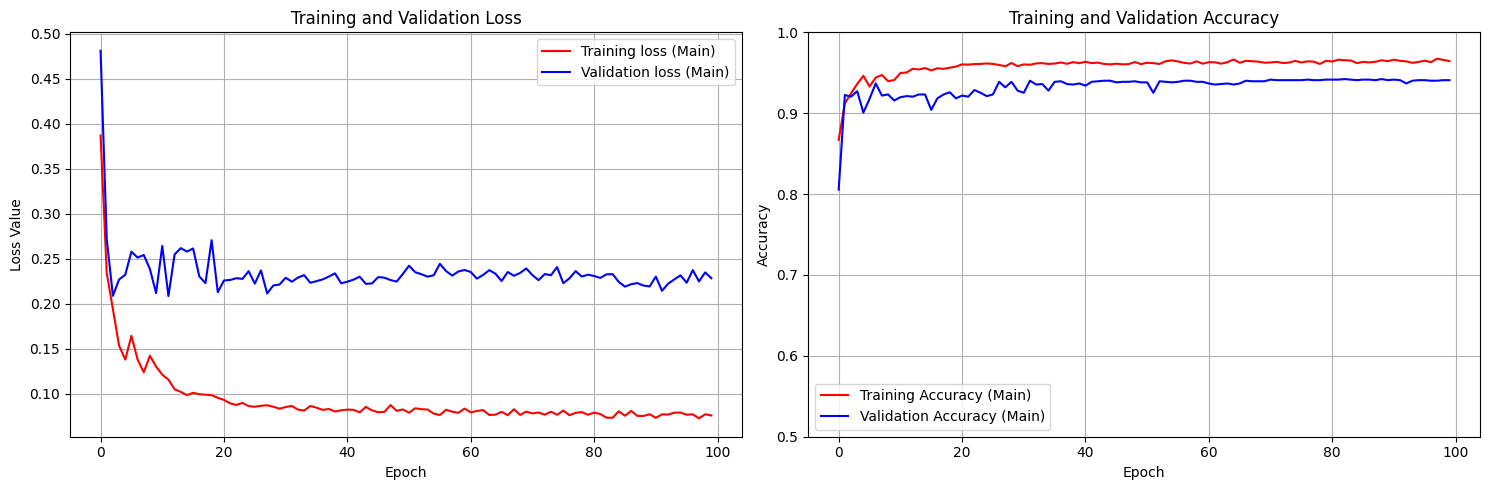

In [ ]:
# loss / accuracy 그래프
train_loss = history.history['loss']
train_accuracy = history.history['accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss (Main)')
plt.plot(val_loss, 'b', label='Validation loss (Main)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0])
plt.plot(train_accuracy, 'r', label='Training Accuracy (Main)')
plt.plot(val_accuracy, 'b', label='Validation Accuracy (Main)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

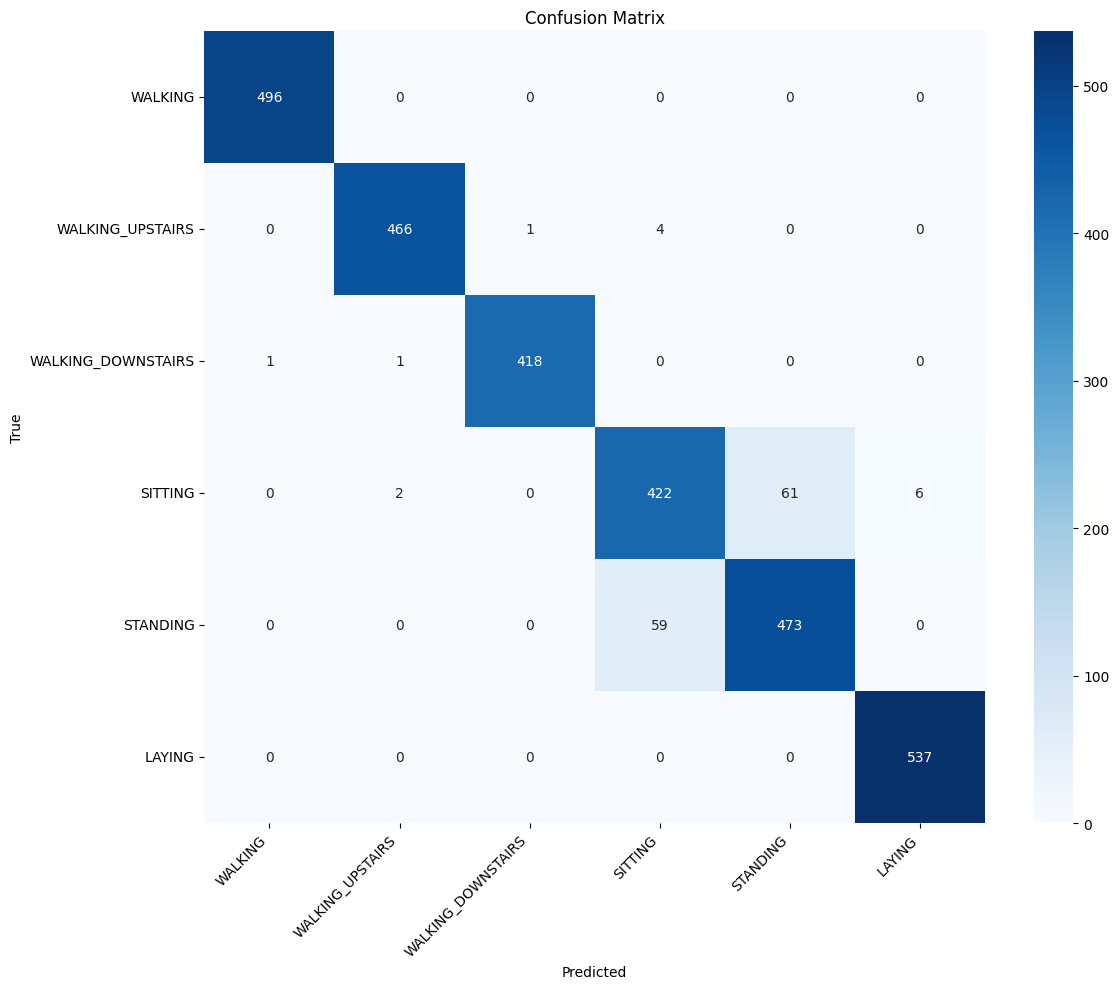

In [ ]:
# 혼동행렬(히트맵)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()